<a href="https://colab.research.google.com/github/babi00/ai4biological-pattern/blob/clean-barbara/barbara_new/region_explainability_clustering_v0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from PIL import Image
from sklearn.preprocessing import StandardScaler
import torch
import umap
import hdbscan
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
from collections import defaultdict
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import tqdm
!pip install open_clip_torch
import open_clip
from google.colab import drive

torch.manual_seed(42)
np.random.seed(42)

drive.mount('/content/drive')

/usr/local/lib/python3.12/dist-packages/hdbscan/plots.py:448: SyntaxWarning: invalid escape sequence '\l'
  axis.set_ylabel('$\lambda$ value')
/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.1 MB/s eta 0:00:00
Mounted at /content/drive


In [6]:
class RegionImageDataset(Dataset):
    def __init__(self, region_dir, transform):
        self.image_paths = [
            os.path.join(region_dir, f)
            for f in os.listdir(region_dir)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ]
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        image = Image.open(path).convert("RGB")
        return self.transform(image), path

In [7]:
from tqdm import tqdm

def get_embeddings_with_dataloader(region_dir, bioclip_model, transform, batch_size=64, num_workers=4, device="cuda"):
    dataset = RegionImageDataset(region_dir, transform)
    dataloader = DataLoader(dataset, batch_size=batch_size, num_workers=num_workers, pin_memory=True)

    embeddings = []
    image_paths = []

    bioclip_model.eval()
    with torch.no_grad():
        for batch_imgs, batch_paths in tqdm(dataloader, desc="Encoding images"):
            batch_imgs = batch_imgs.to(device, non_blocking=True)
            batch_embs = bioclip_model.encode_image(batch_imgs)
            embeddings.append(batch_embs.cpu())
            image_paths.extend(batch_paths)

    return image_paths, torch.cat(embeddings).numpy()


In [8]:
def get_bioclip_embeddings_extractor_model(device, bioclip_version=2):
    if bioclip_version==2:
        print("BioCLIP 2!")
        model, _, preprocess = open_clip.create_model_and_transforms('hf-hub:imageomics/bioclip-2')
    else:
        model, _, preprocess = open_clip.create_model_and_transforms('hf-hub:imageomics/bioclip')
    print("Model obtained...")
    model.to(device)
    model.eval()
    return model, preprocess

In [9]:
def load_region_images(region_dir, transform):
    image_paths = []
    tensors = []

    for file in os.listdir(region_dir):
        if file.endswith(".png") or file.endswith(".jpg"):
            path = os.path.join(region_dir, file)
            img = Image.open(path).convert("RGB")
            tensor = transform(img)
            image_paths.append(path)
            tensors.append(tensor)

    return image_paths, torch.stack(tensors)

In [10]:
def encode_regions_with_bioclip(region_tensors, bioclip_model, batch_size=16, device="cuda"):
    bioclip_model.eval()
    embeddings = []

    with torch.no_grad():
        for i in range(0, len(region_tensors), batch_size):
            batch = region_tensors[i:i + batch_size].to(device)
            emb = bioclip_model.encode_image(batch)
            embeddings.append(emb.cpu())

    return torch.cat(embeddings).numpy()

In [11]:
def cluster_embeddings_with_umap_hdbscan(embeddings, min_cluster_size=15, n_neighbors=15, min_dist=0.1, metric="euclidean"):
    reducer = umap.UMAP(n_neighbors=n_neighbors, min_dist=min_dist, metric=metric, random_state=42)
    reduced = reducer.fit_transform(embeddings)

    clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, metric=metric)
    cluster_labels = clusterer.fit_predict(reduced)

    return reduced, cluster_labels

In [12]:
def visualize_cluster_samples(image_paths, cluster_labels, num_per_cluster=10, output_dir="cluster_previews"):
    os.makedirs(output_dir, exist_ok=True)

    clusters = defaultdict(list)
    for path, label in zip(image_paths, cluster_labels):
        clusters[label].append(path)

    for label, paths in clusters.items():
        if label == -1:
            continue  # noise

        fig, axs = plt.subplots(1, min(num_per_cluster, len(paths)), figsize=(20, 4))
        fig.suptitle(f"Cluster {label}")

        for i, img_path in enumerate(paths[:num_per_cluster]):
            img = Image.open(img_path)
            axs[i].imshow(img)
            axs[i].axis("off")
            axs[i].set_title(os.path.basename(img_path))

        plt.tight_layout()
        plt.show()
        plt.close()

Save cluster mapping in a csv file

In [13]:
import pandas as pd

def save_cluster_mapping_csv(image_paths, cluster_labels, output_path="region_cluster_mapping.csv"):
    df = pd.DataFrame({
        "image_path": image_paths,
        "cluster_id": cluster_labels
    })
    df.to_csv(output_path, index=False)
    print(f"Cluster mapping saved to {output_path}")


In [ ]:
save_cluster_mapping_csv(region_paths, cluster_labels, output_path="/content/drive/MyDrive/TESI - PoliTO/region_cluster_mapping.csv")

Cluster summary

In [14]:
import pandas as pd
import numpy as np
import os
from collections import Counter
from sklearn.metrics import pairwise_distances

def summarize_clusters(csv_path, embeddings, image_paths):
    df = pd.read_csv(csv_path)
    df["embedding"] = list(embeddings)  # each row gets the corresponding embedding

    cluster_counts = df["cluster_id"].value_counts().sort_index()
    num_clusters = (df["cluster_id"].nunique()) - (1 if -1 in df["cluster_id"].values else 0)
    num_noise = (df["cluster_id"] == -1).sum()

    print(f"📊 Total clusters (excluding noise): {num_clusters}")
    print(f"⚠️ Noise points: {num_noise}")
    print("\n📦 Cluster sizes:")
    print(cluster_counts)

    # Optional: Cluster centroids and compactness
    cluster_stats = []
    for cluster_id in sorted(df["cluster_id"].unique()):
        if cluster_id == -1:
            continue

        cluster_data = df[df["cluster_id"] == cluster_id]
        embeddings_cluster = np.stack(cluster_data["embedding"].values)

        # Compute centroid
        centroid = embeddings_cluster.mean(axis=0)

        # Compute intra-cluster distances (compactness)
        distances = pairwise_distances(embeddings_cluster, [centroid])
        avg_dist = distances.mean()

        cluster_stats.append({
            "cluster_id": cluster_id,
            "size": len(cluster_data),
            "avg_intra_dist": avg_dist
        })

    cluster_stats_df = pd.DataFrame(cluster_stats)
    print("\n📏 Cluster compactness (avg. distance to centroid):")
    print(cluster_stats_df.sort_values("avg_intra_dist"))

    return cluster_stats_df
csv_path = "/content/drive/MyDrive/TESI - PoliTO/region_cluster_mapping.csv"




In [ ]:
cluster_stats_df = summarize_clusters(csv_path, embeddings, region_paths)

Save embeddings

In [15]:
import numpy as np

def save_embeddings_npz(image_paths, embeddings, save_path):
    embedding_dict = {
        os.path.basename(path): emb for path, emb in zip(image_paths, embeddings)
    }
    np.savez_compressed(save_path, **embedding_dict)
    print(f"✅ Embeddings saved to: {save_path}")
save_path = "/content/drive/MyDrive/TESI - PoliTO/region_embeddings_bioclip2.npz"


In [ ]:
save_embeddings_npz(region_paths, embeddings, save_path)

Copying each image in its cluster folder

In [16]:
import pandas as pd
import os
import shutil
from google.colab import drive
drive.mount('/content/drive')

def organize_images_by_cluster(csv_path, output_base_dir):
    df = pd.read_csv(csv_path)

    for _, row in df.iterrows():
        image_path = row["image_path"]
        cluster_id = row["cluster_id"]

        if cluster_id == -1:
            cluster_folder = os.path.join(output_base_dir, f"noise_cluster")
        else:
            cluster_folder = os.path.join(output_base_dir, f"cluster_{cluster_id}")
        os.makedirs(cluster_folder, exist_ok=True)

        image_filename = os.path.basename(image_path)
        target_path = os.path.join(cluster_folder, image_filename)

        try:
            shutil.copy(image_path, target_path)
        except Exception as e:
            print(f"Failed to copy {image_path} → {target_path}: {e}")

    print(f"✅ Images organized into folders under: {output_base_dir}")

csv_path = "/content/drive/MyDrive/TESI - PoliTO/region_cluster_mapping.csv"
output_base_dir = "/content/drive/MyDrive/TESI - PoliTO/clustered_regions"



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
organize_images_by_cluster(csv_path, output_base_dir)

Basic stats

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

def analyze_cluster_csv(csv_path, top_n=5, plot=True):
    df = pd.read_csv(csv_path)

    total_samples = len(df)
    noise_points = df[df["cluster_id"] == -1]
    clustered_points = df[df["cluster_id"] != -1]
    num_clusters = clustered_points["cluster_id"].nunique()

    print(f"📦 Total samples: {total_samples}")
    print(f"⚠️ Noise points: {len(noise_points)} ({len(noise_points)/total_samples:.2%})")
    print(f"🔢 Number of clusters (excluding noise): {num_clusters}")

    cluster_sizes = df[df["cluster_id"] != -1]["cluster_id"].value_counts().sort_values(ascending=False)
    min_size = cluster_sizes.min()
    max_size = cluster_sizes.max()
    mean_size = cluster_sizes.mean()

    print(f"\n📉 Cluster size stats:")
    print(f"   Min: {min_size}")
    print(f"   Max: {max_size}")
    print(f"   Mean: {mean_size:.2f}")

    print(f"\n🔝 Top {top_n} largest clusters:")
    print(cluster_sizes.head(top_n))

    if plot:
        plt.figure(figsize=(10, 4))
        cluster_sizes.plot(kind='bar')
        plt.title("📊 Cluster Sizes")
        plt.xlabel("Cluster ID")
        plt.ylabel("Number of Images")
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()

    return {
        "total_samples": total_samples,
        "noise_points": len(noise_points),
        "num_clusters": num_clusters,
        "min_size": min_size,
        "max_size": max_size,
        "mean_size": mean_size,
        "cluster_sizes": cluster_sizes
    }
csv_path = "/content/drive/MyDrive/TESI - PoliTO/region_cluster_mapping.csv"


In [17]:
def region_embedding_and_clustering(region_dir="final_regions_bioclip", model_name="no_hys_remove_from_val",model_dir="invasive_species",folder_name="taxas",
                                    use_bioclip=True, bioclip_version=2, save_embeddings=True, embeddings_path="final_region_embeddings_bioclip2.npz", integrated_gradients=False, shap=False):
    torch.cuda.empty_cache()


    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model_name = f'bioclip_2_{model_name}' if use_bioclip and bioclip_version==2 else f'bioclip_1_{model_name}' if use_bioclip else f'resnet_{model_name}'
    classifier_path = f'/content/drive/MyDrive/TESI - PoliTO/{model_dir}/classifier_head_{model_name}.pth'
    github = '/content/ai4biological-pattern/barbara_new'
    github_repository = f'{github}/{folder_name}'

    region_dir = f"ig_{region_dir}" if integrated_gradients else f"shap_{region_dir}" if shap else region_dir
    embeddings_path = f"ig_{embeddings_path}" if integrated_gradients else f"shap_{embeddings_path}" if shap else embeddings_path
    embeddings_path = f"/content/drive/MyDrive/TESI - PoliTO/{embeddings_path}"

    feature_extractor, preprocess = get_bioclip_embeddings_extractor_model(device, bioclip_version=bioclip_version)
    feature_extractor.eval().to(device)

    region_drive_path = f"/content/drive/MyDrive/TESI - PoliTO/{region_dir}"
    region_paths, tensors = load_region_images(region_drive_path, preprocess)
    print(f"Loaded {len(region_paths)} regions...")
    embeddings = encode_regions_with_bioclip(tensors, feature_extractor, batch_size=16, device=device)
    print(f"Embeddings extracted...")

    if save_embeddings:
        save_embeddings_npz(region_paths, embeddings, save_path=embeddings_path)
        print(f"Embeddings saved to {embeddings_path}")

    reduced, cluster_labels = cluster_embeddings_with_umap_hdbscan(embeddings, min_cluster_size=15)
    print(f"Clustered...")

    print(cluster_labels)

    visualize_cluster_samples(region_paths, cluster_labels, num_per_cluster=10)

    return reduced, cluster_labels, region_paths


BioCLIP 2!
Model obtained...
Loaded 5931 regions...
Embeddings extracted...
✅ Embeddings saved to: /content/drive/MyDrive/TESI - PoliTO/ig_final_region_embeddings_bioclip2.npz


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Clustered...
[19  6  6 ... -1 11 12]


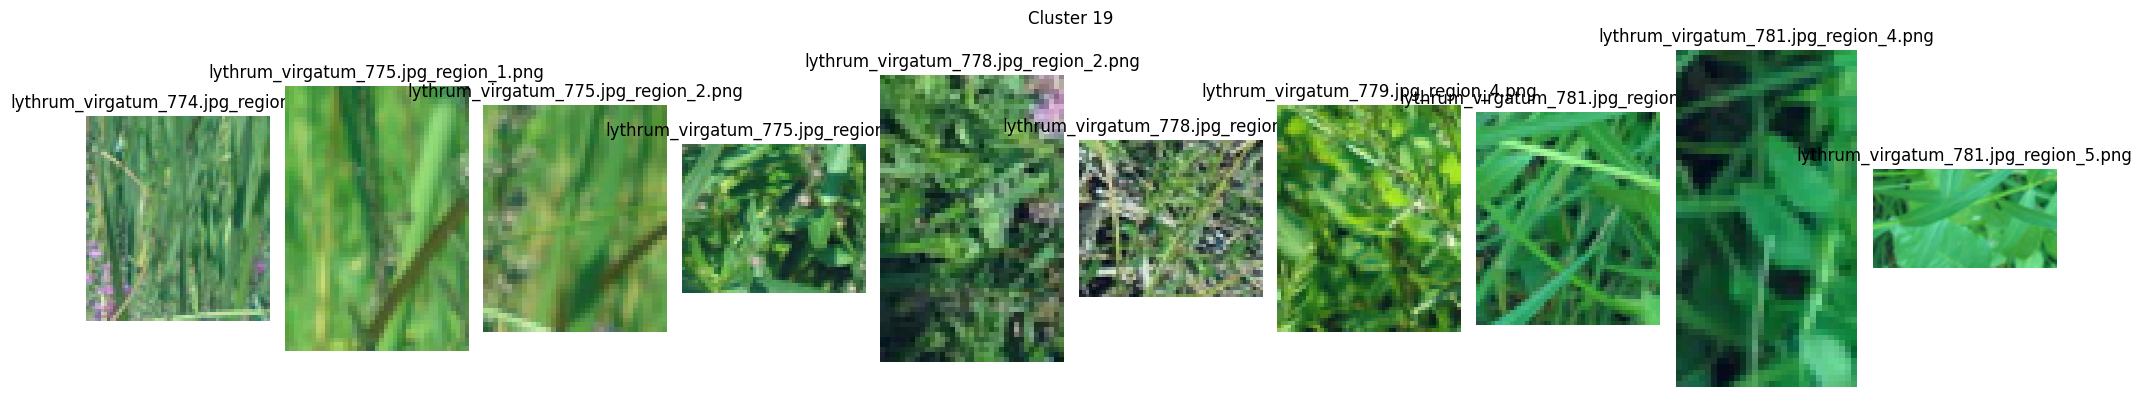

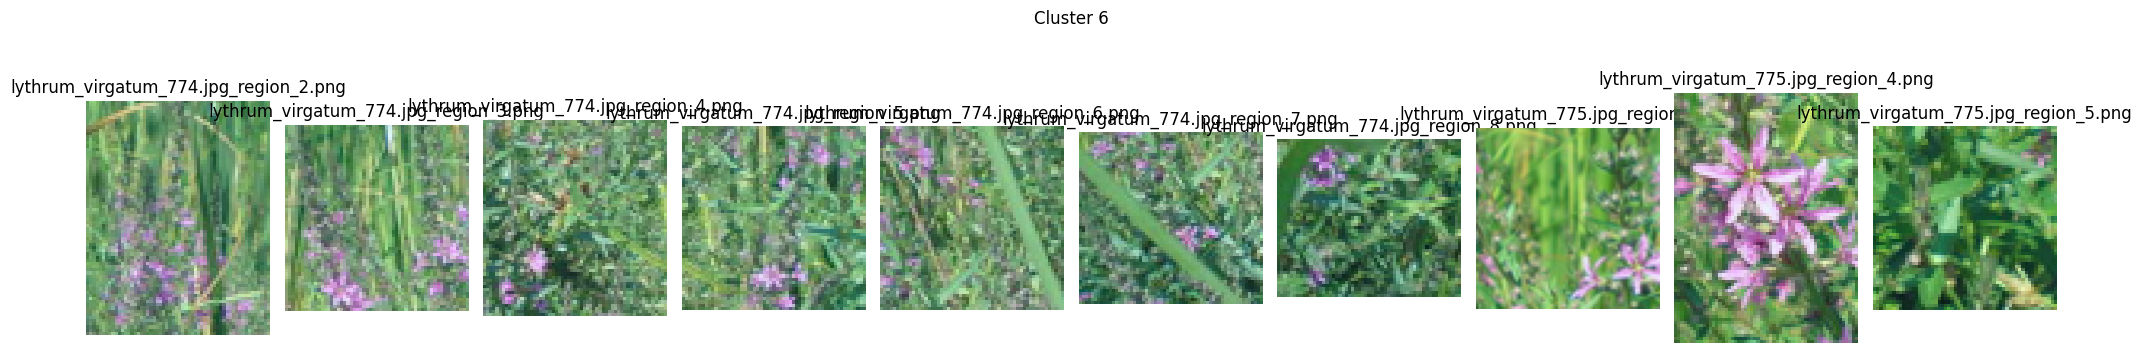

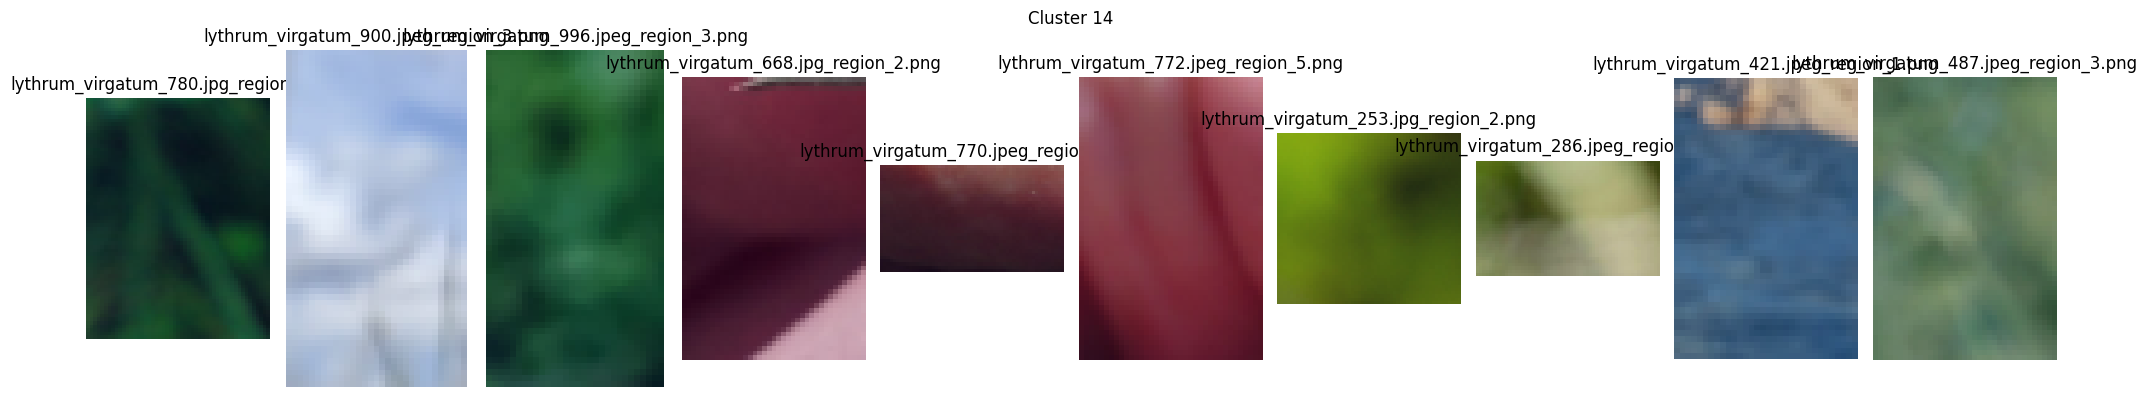

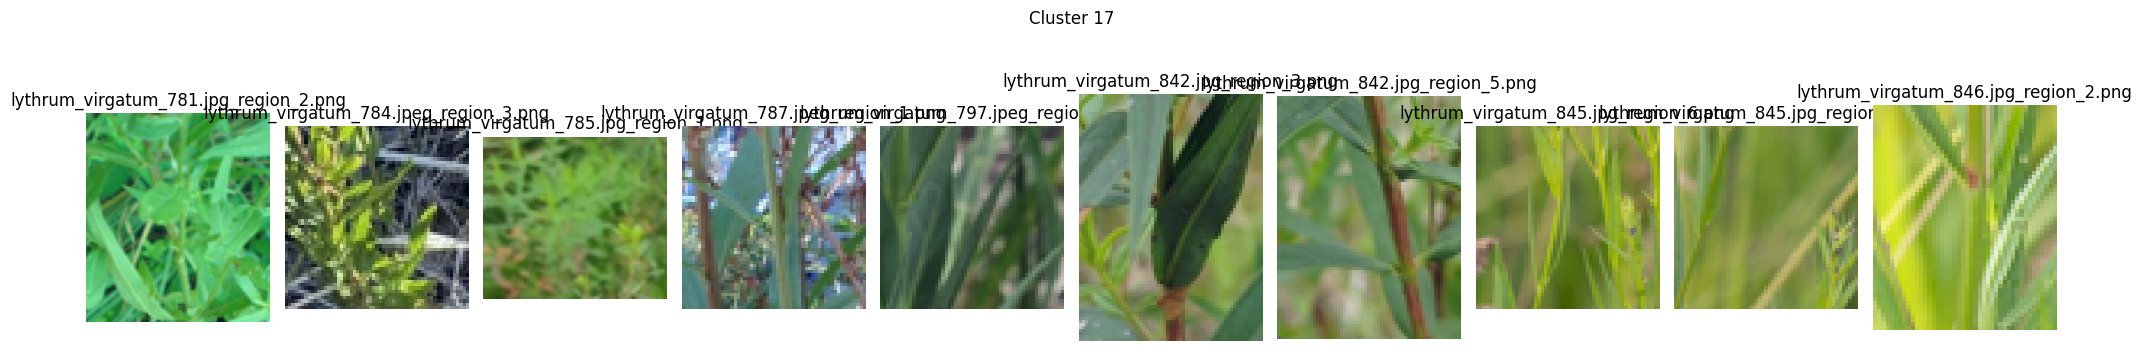

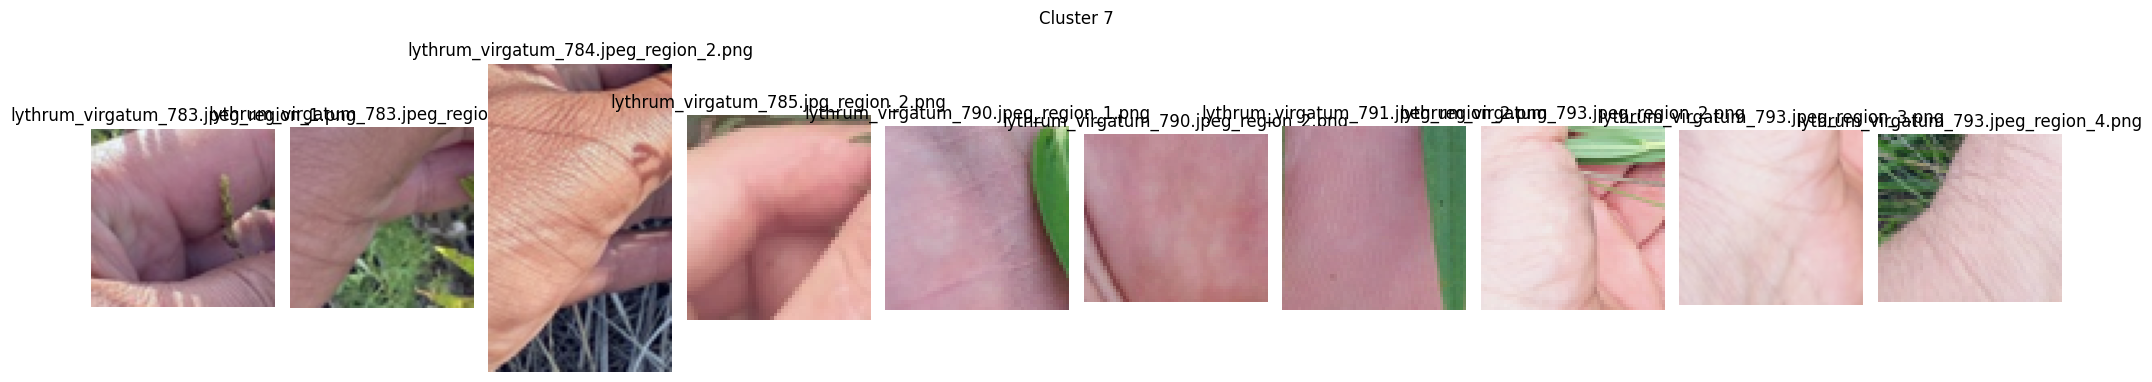

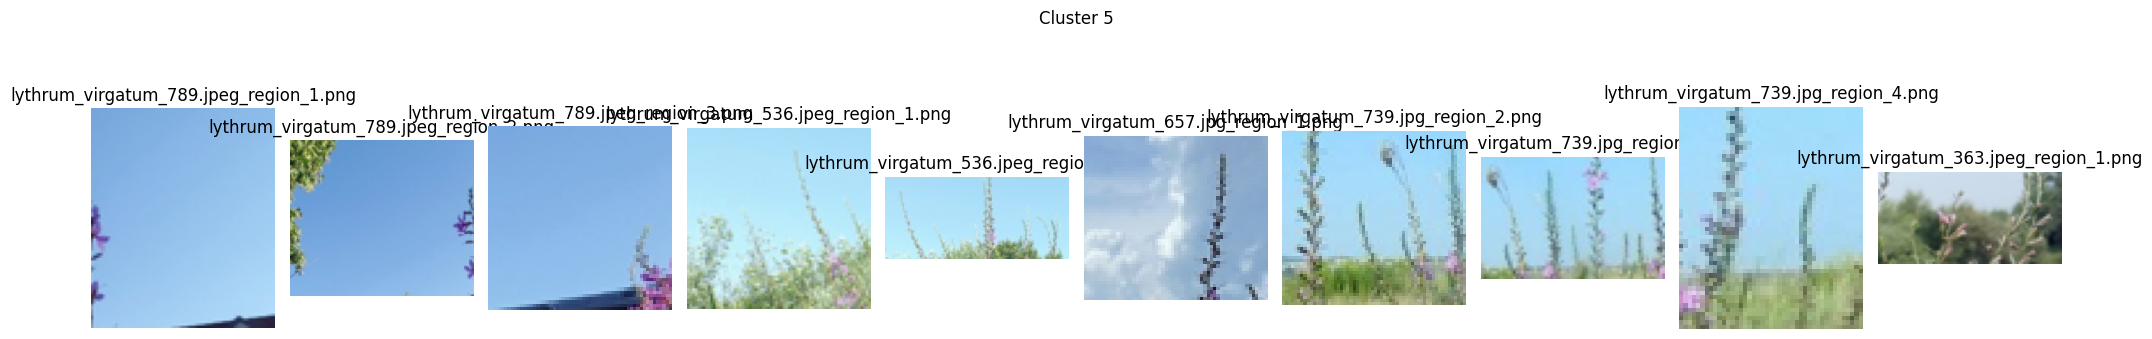

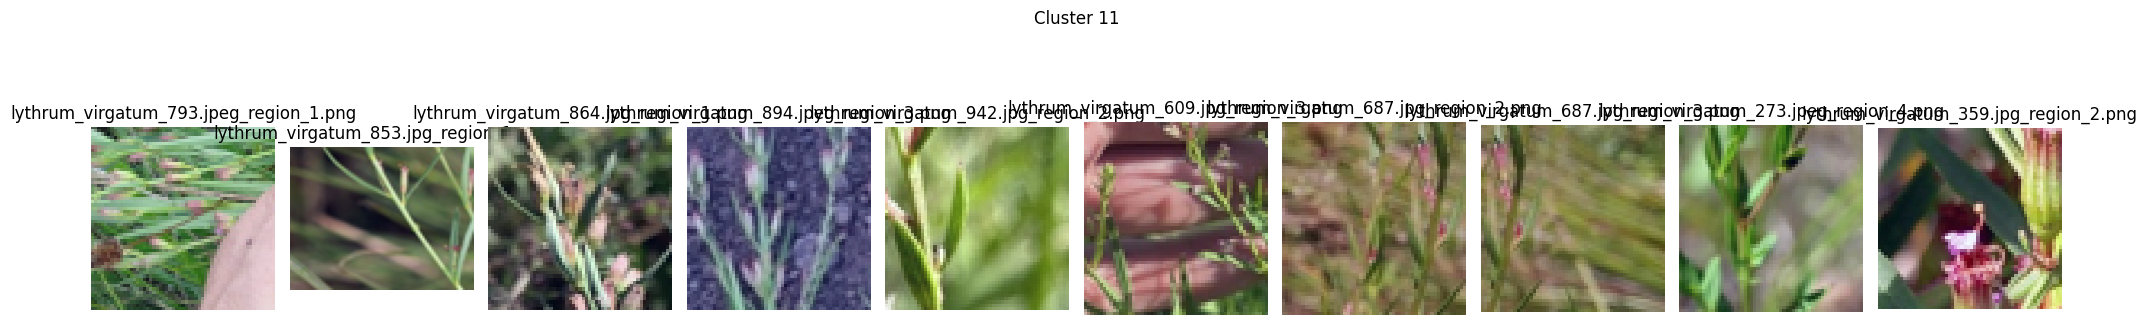

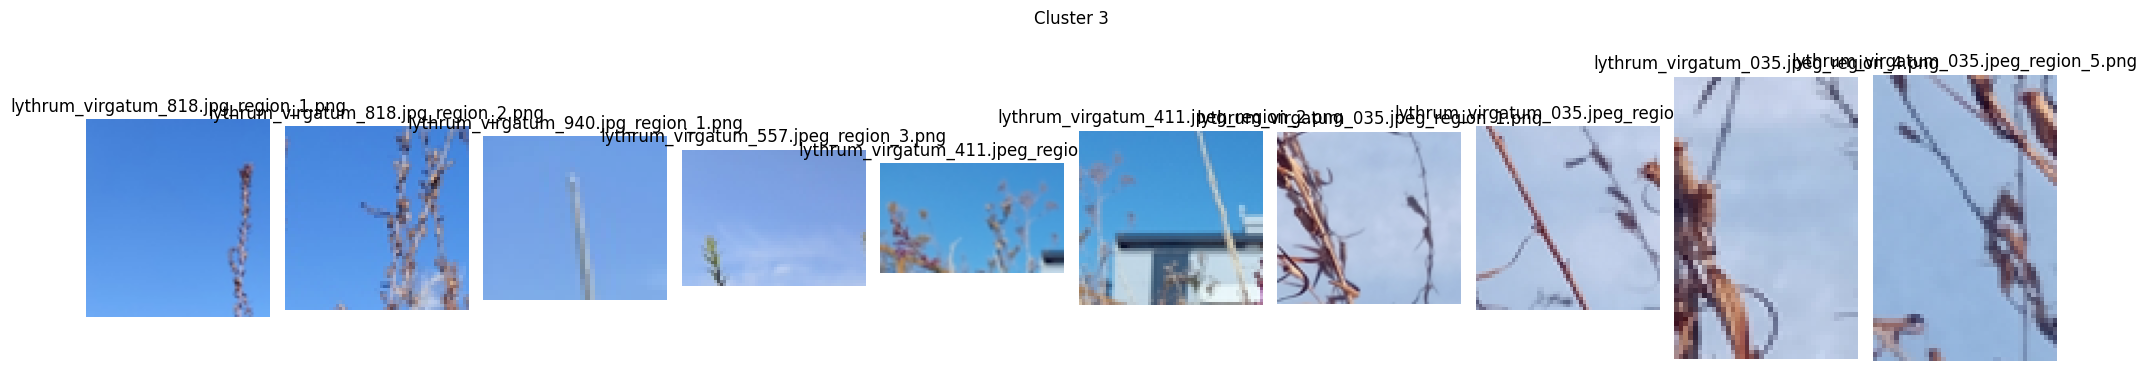

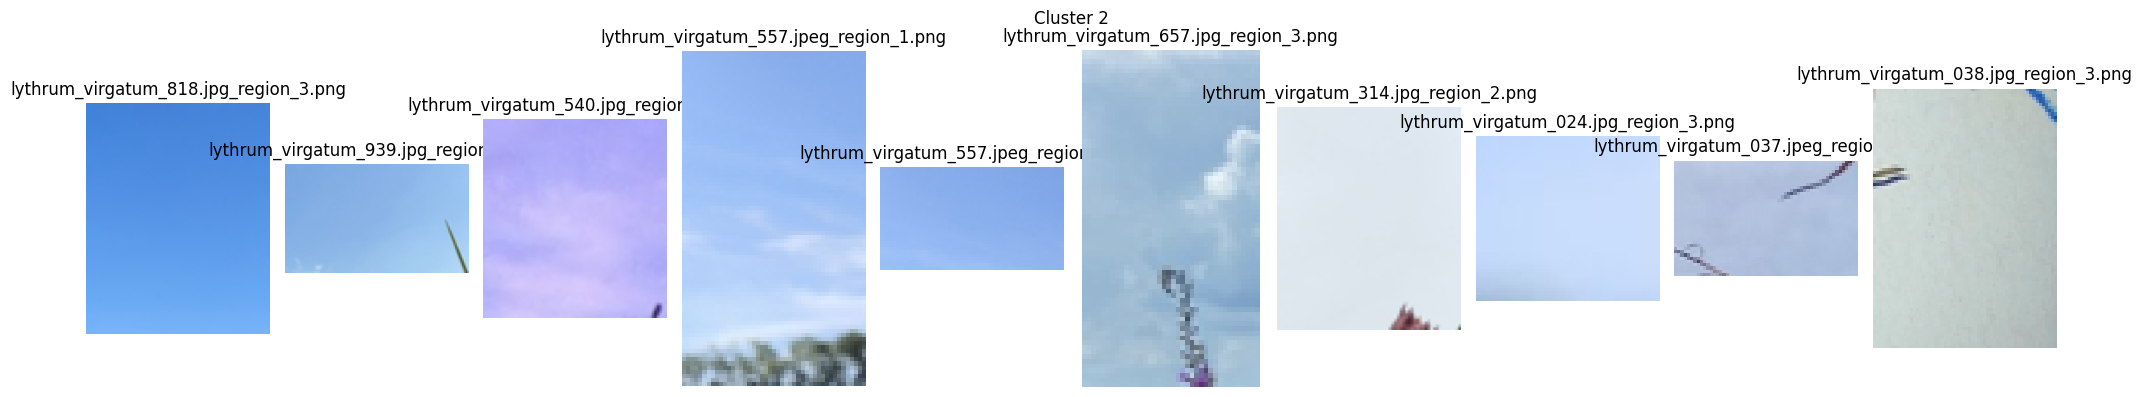

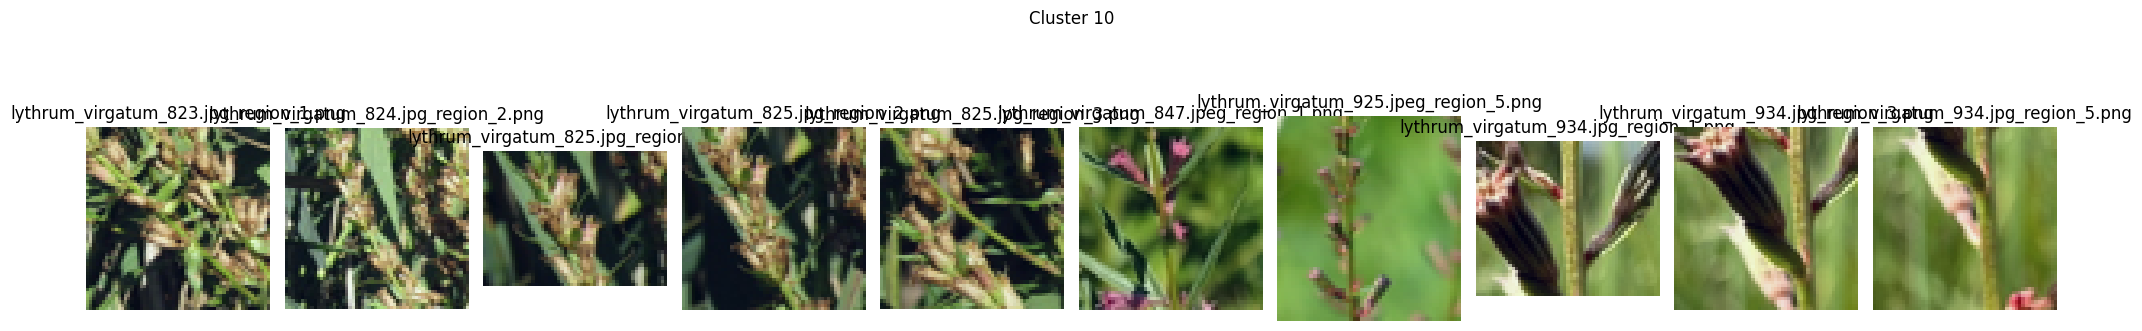

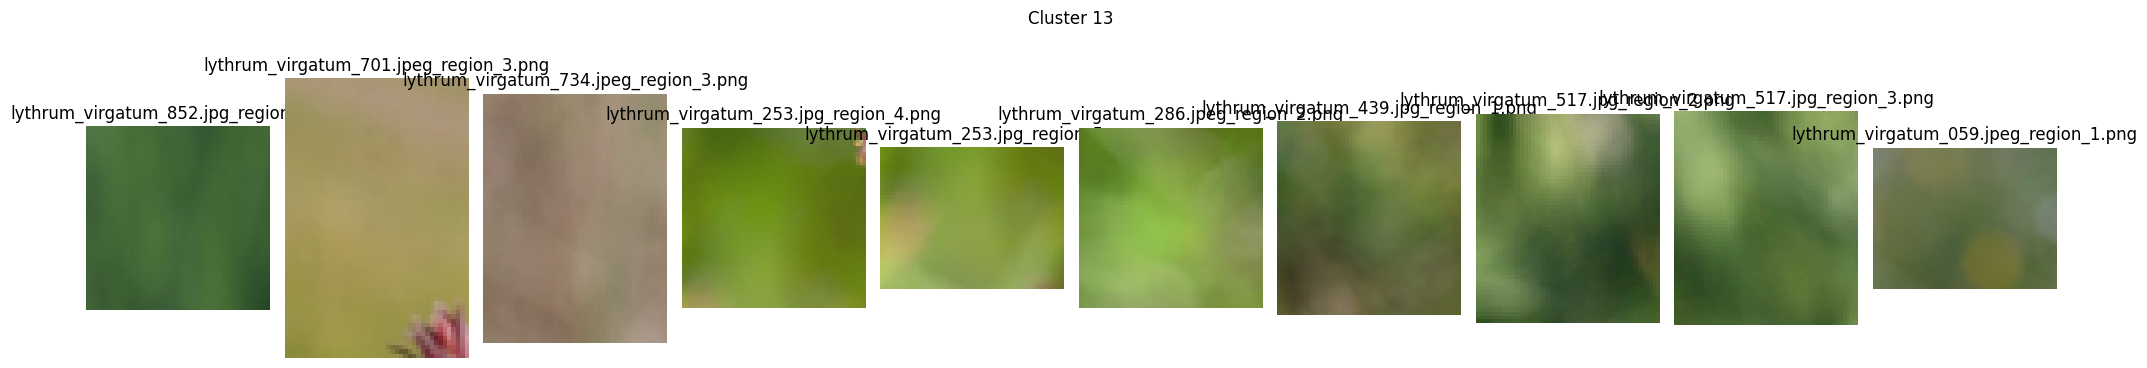

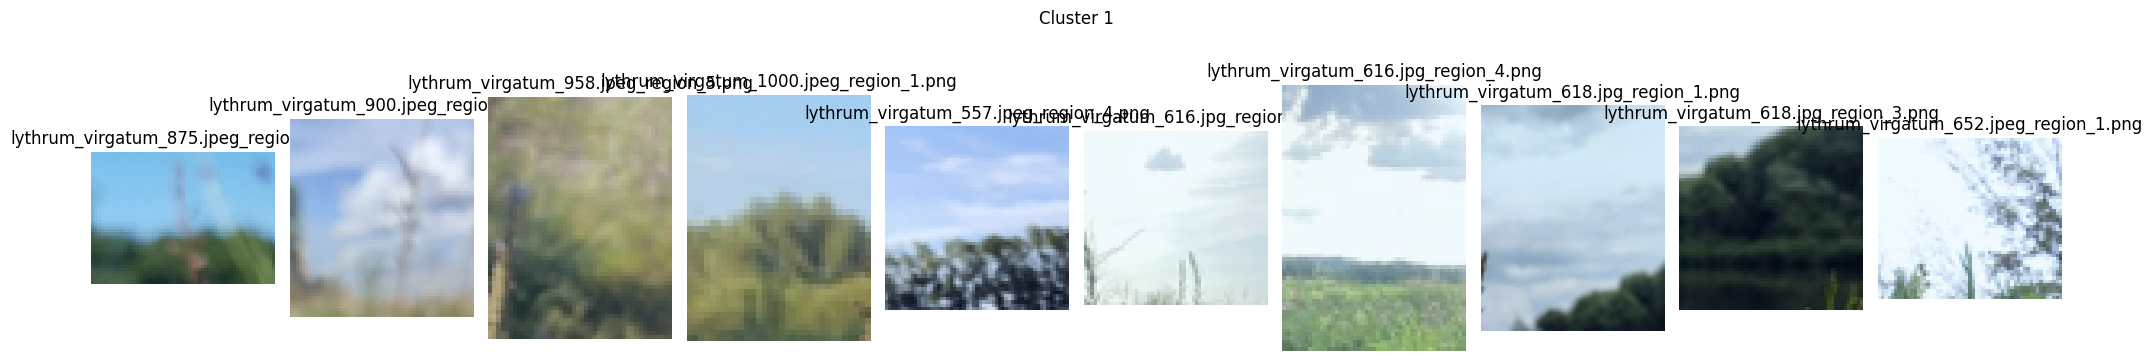

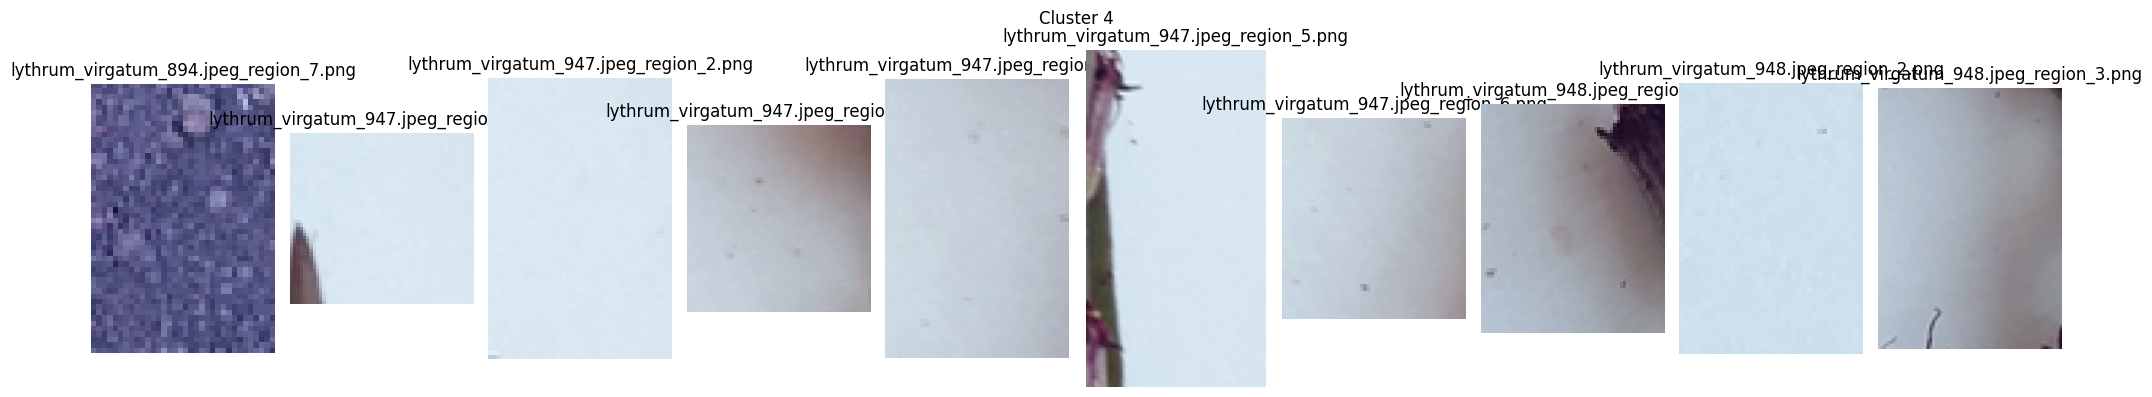

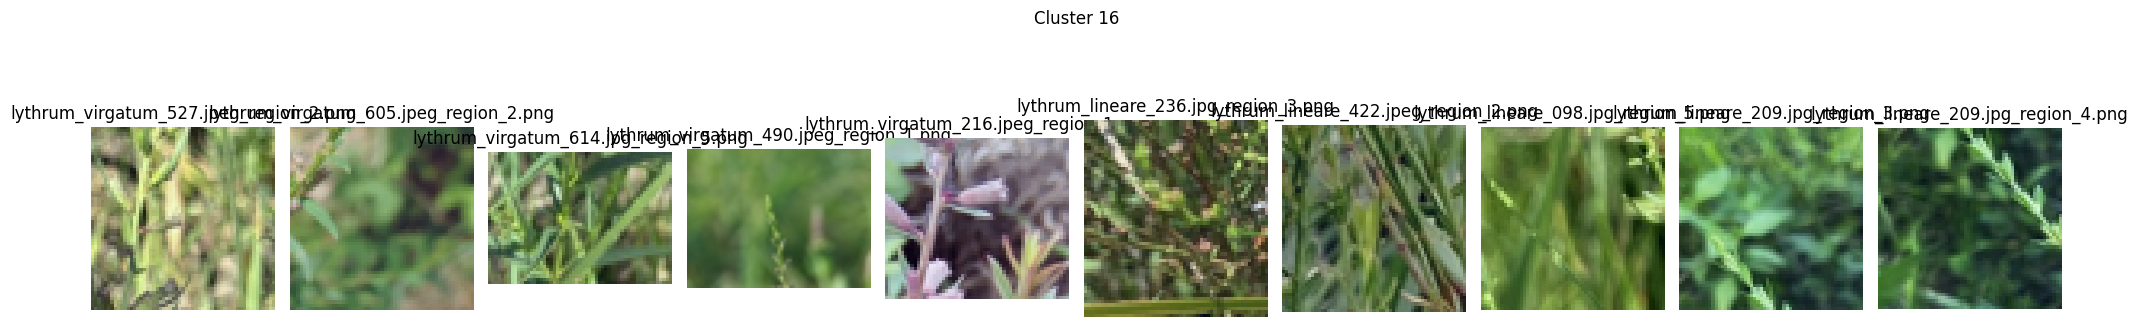

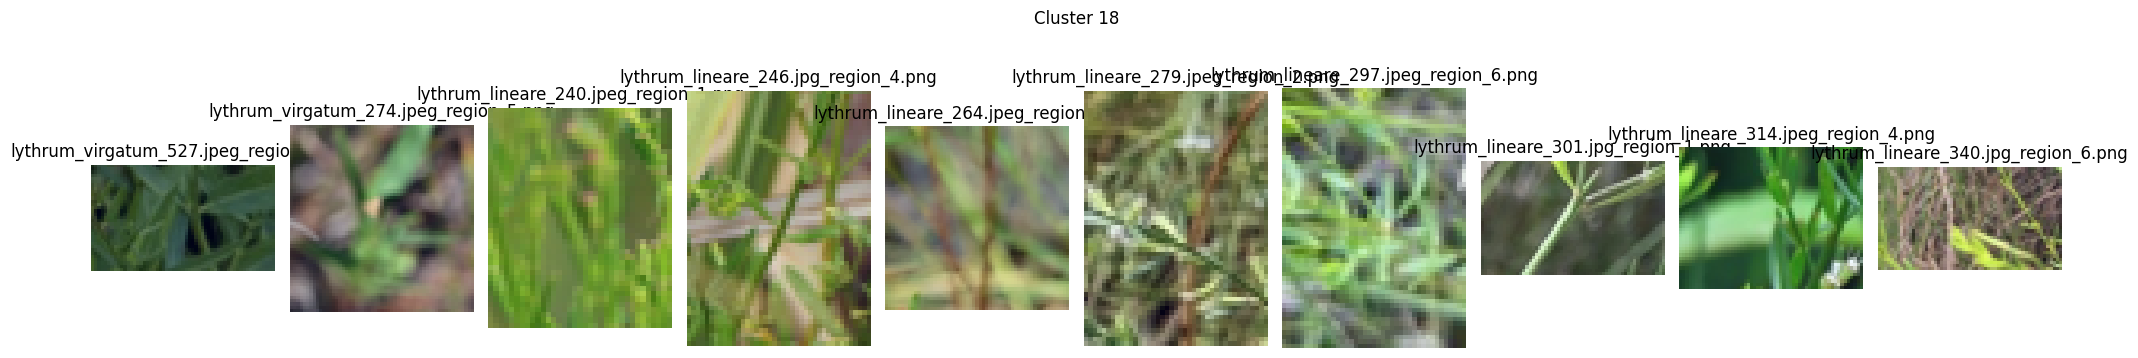

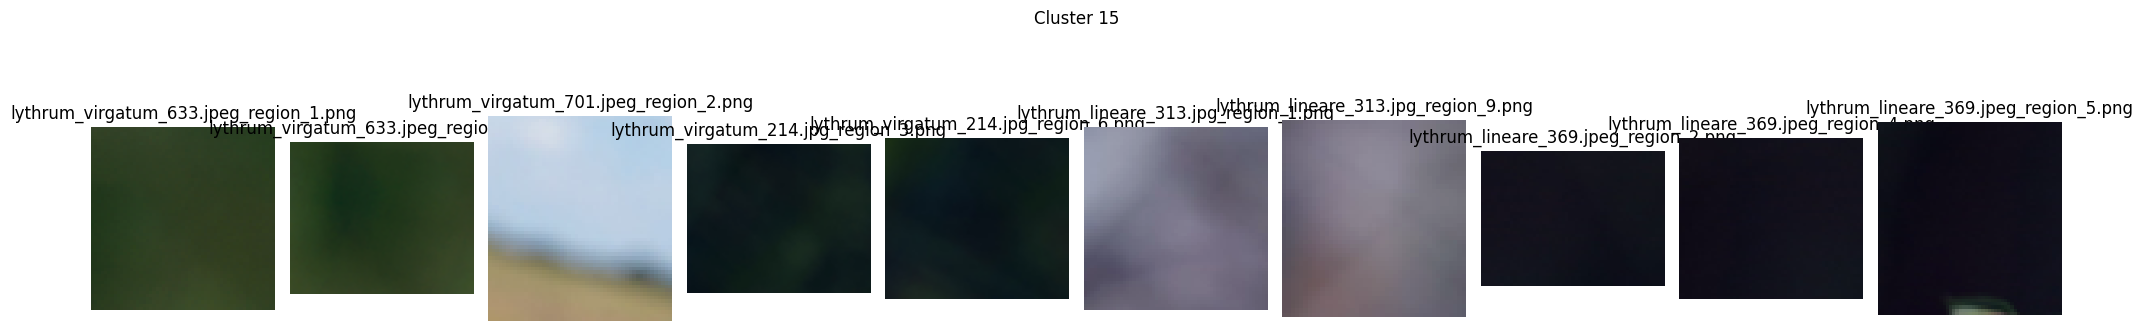

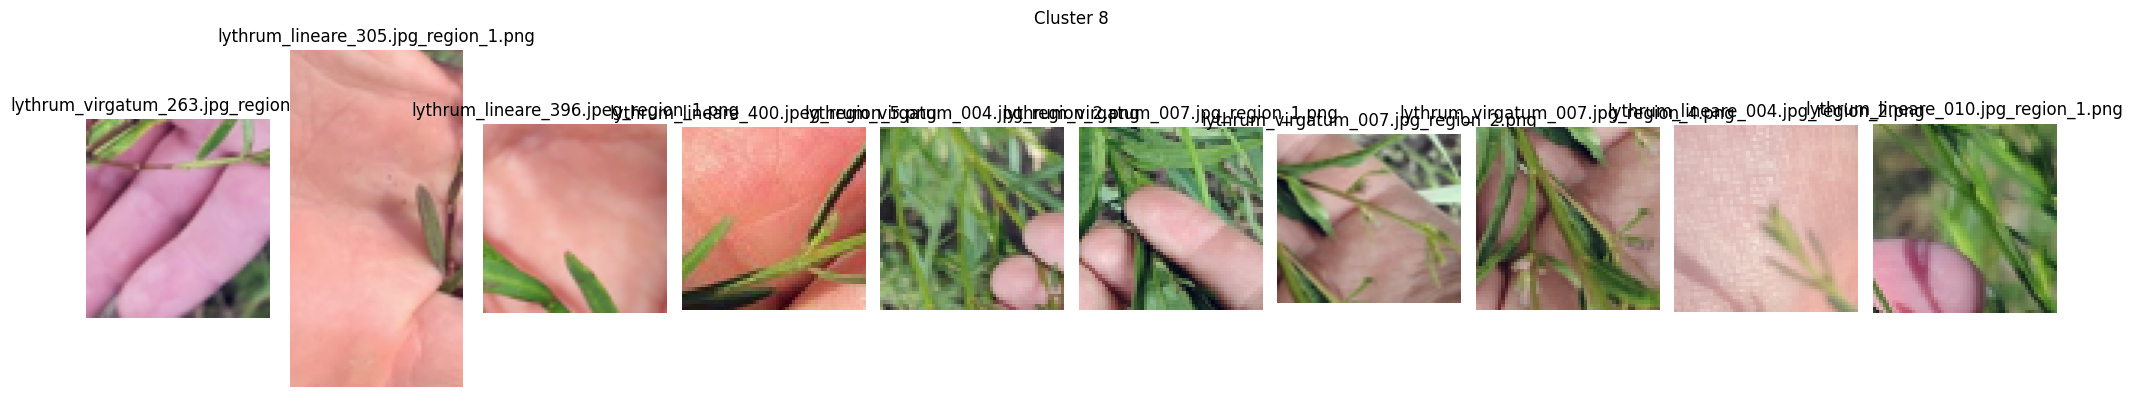

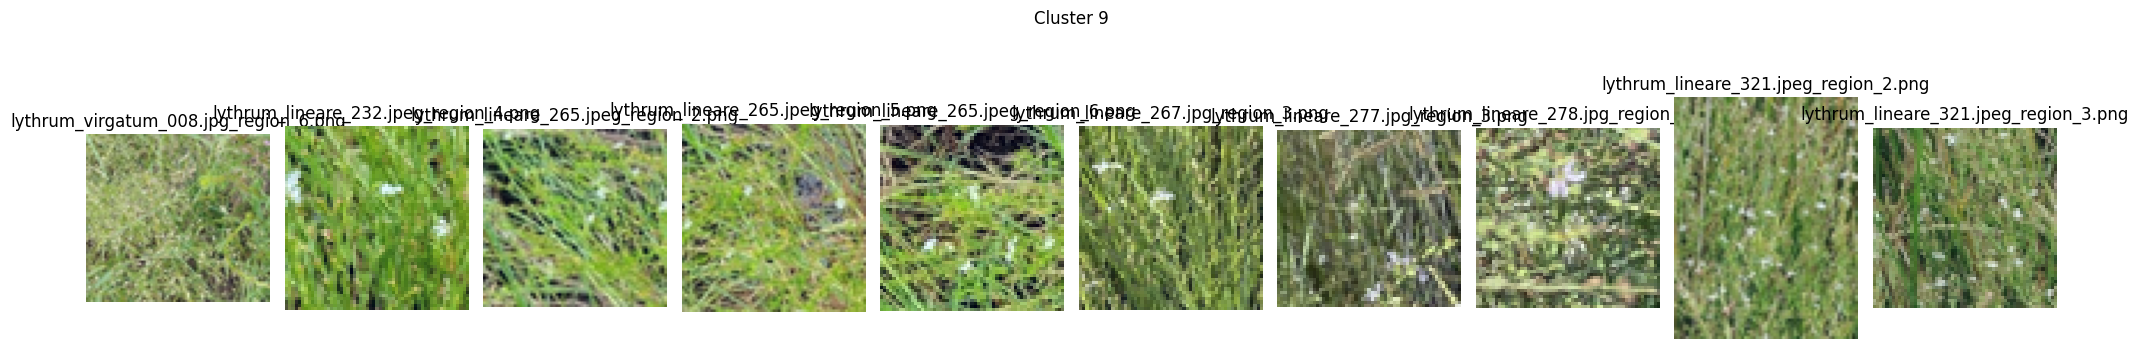

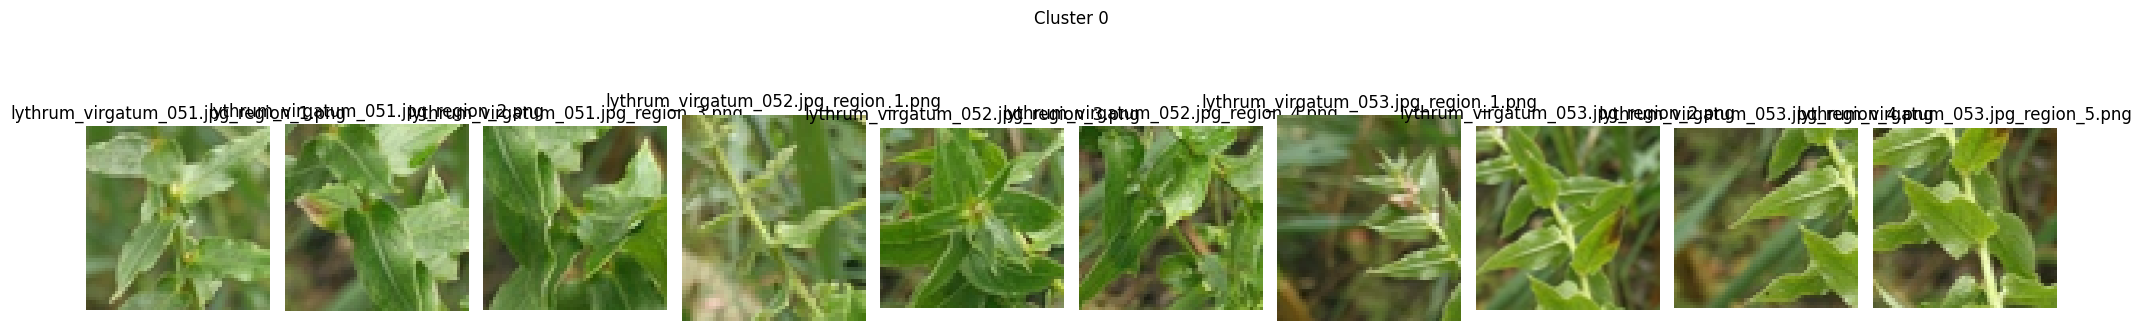

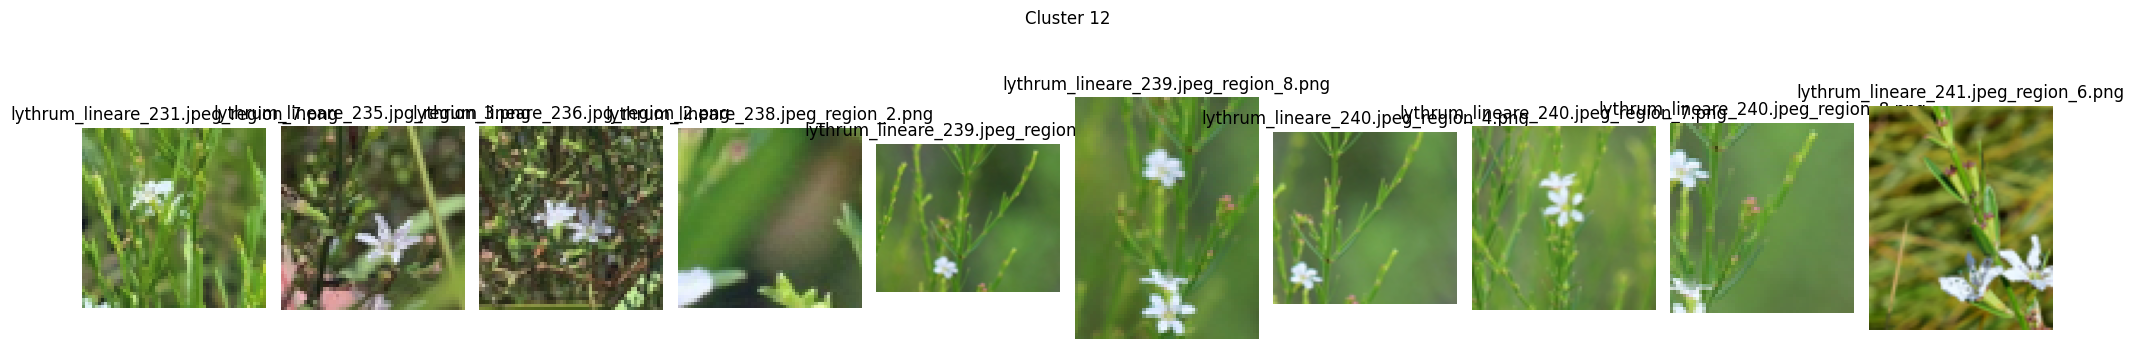

(array([[5.8474884, 2.760617 ],
        [9.114788 , 4.372531 ],
        [9.066283 , 4.336689 ],
        ...,
        [4.291288 , 5.3430753],
        [4.0572925, 5.9954   ],
        [4.626012 , 7.9303513]], dtype=float32),
 array([19,  6,  6, ..., -1, 11, 12]),
 ['/content/drive/MyDrive/TESI - PoliTO/ig_final_regions_bioclip/lythrum_virgatum_774.jpg_region_1.png',
  '/content/drive/MyDrive/TESI - PoliTO/ig_final_regions_bioclip/lythrum_virgatum_774.jpg_region_2.png',
  '/content/drive/MyDrive/TESI - PoliTO/ig_final_regions_bioclip/lythrum_virgatum_774.jpg_region_3.png',
  '/content/drive/MyDrive/TESI - PoliTO/ig_final_regions_bioclip/lythrum_virgatum_774.jpg_region_4.png',
  '/content/drive/MyDrive/TESI - PoliTO/ig_final_regions_bioclip/lythrum_virgatum_774.jpg_region_5.png',
  '/content/drive/MyDrive/TESI - PoliTO/ig_final_regions_bioclip/lythrum_virgatum_774.jpg_region_6.png',
  '/content/drive/MyDrive/TESI - PoliTO/ig_final_regions_bioclip/lythrum_virgatum_774.jpg_region_7.png',
  '/

In [18]:
region_embedding_and_clustering(integrated_gradients=True)

Load embeddings and try different clustering techniques

In [23]:
def load_embeddings_and_cluster(region_dir="final_regions_bioclip", model_name="no_hys_remove_from_val",model_dir="invasive_species",folder_name="taxas",
                                    use_bioclip=True, bioclip_version=2, integrated_gradients=False, shap=False, embeddings_path="final_region_embeddings_bioclip2.npz",
                                min_cluster_size=10, n_neighbors=5, min_dist=0.1, metric="euclidean", name_configuration="configuration_0", copy_images_to_cluster_folders=False):

    region_dir = f"ig_{region_dir}" if integrated_gradients else f"shap_{region_dir}" if shap else region_dir

    embedding_model = "ig" if integrated_gradients else "shap" if shap else ""

    print(f"{name_configuration}\n------- \nEmbedding model: {embedding_model}\nEmbedding path: {embeddings_path}\nMin cluster size: {min_cluster_size}\nNumber of neighbors: {n_neighbors}\nMin distance: {min_dist}\nMetric: {metric}\n-------\n")



    torch.cuda.empty_cache()

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model_name = f'bioclip_2_{model_name}' if use_bioclip and bioclip_version==2 else f'bioclip_1_{model_name}' if use_bioclip else f'resnet_{model_name}'
    classifier_path = f'/content/drive/MyDrive/TESI - PoliTO/{model_dir}/classifier_head_{model_name}.pth'
    github = '/content/ai4biological-pattern/barbara_new'
    github_repository = f'{github}/{folder_name}'


    embeddings_path = f"/content/drive/MyDrive/TESI - PoliTO/{embedding_model}_{embeddings_path}"
    data = np.load(embeddings_path, allow_pickle=True)
    image_filenames = list(data.keys())
    embeddings = [data[filename] for filename in image_filenames]
    region_dir = f"/content/drive/MyDrive/TESI - PoliTO/{region_dir}"
    region_paths = [os.path.join(region_dir, filename) for filename in image_filenames]

    reduced, cluster_labels = cluster_embeddings_with_umap_hdbscan(embeddings, min_cluster_size=min_cluster_size, n_neighbors=n_neighbors, min_dist=min_dist, metric=metric)
    print(f"Clustered...")

    csv_pat = f"/content/drive/MyDrive/TESI - PoliTO/region_cluster_mapping_{name_configuration}_{embedding_model}.csv"
    save_cluster_mapping_csv(region_paths, cluster_labels, output_path=csv_path)

    cluster_stats_df = summarize_clusters(csv_path, embeddings, region_paths)
    #visualize_cluster_samples(region_paths, cluster_labels, num_per_cluster=10)
    cluster_summary = analyze_cluster_csv(csv_path)

    if copy_images_to_cluster_folders:
        output_base_dir = f"/content/drive/MyDrive/TESI - PoliTO/clustered_regions_{name_configuration}_{embedding_model}"
        organize_images_by_cluster(csv_path, output_base_dir)

configuration_0
------- 
Embedding model: ig
Embedding path: final_region_embeddings_bioclip2.npz
Min cluster size: 10
Number of neighbors: 5
Min distance: 0.2
Metric: euclidean
-------



/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Clustered...
Cluster mapping saved to /content/drive/MyDrive/TESI - PoliTO/region_cluster_mapping.csv
📊 Total clusters (excluding noise): 2
⚠️ Noise points: 18

📦 Cluster sizes:
cluster_id
-1      18
 0      12
 1    5901
Name: count, dtype: int64

📏 Cluster compactness (avg. distance to centroid):
   cluster_id  size  avg_intra_dist
0           0    12       15.839107
1           1  5901       21.639744
📦 Total samples: 5931
⚠️ Noise points: 18 (0.30%)
🔢 Number of clusters (excluding noise): 2

📉 Cluster size stats:
   Min: 12
   Max: 5901
   Mean: 2956.50

🔝 Top 5 largest clusters:
cluster_id
1    5901
0      12
Name: count, dtype: int64


/tmp/ipython-input-634327281.py:36: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


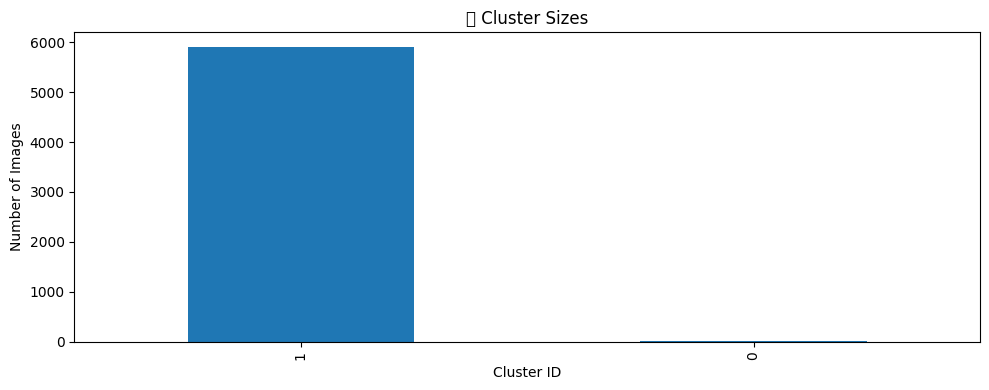

In [27]:
load_embeddings_and_cluster(integrated_gradients=True, name_configuration="configuration_0", min_cluster_size=10, n_neighbors=5, min_dist=0.2, metric="euclidean", copy_images_to_cluster_folders=False)

configuration_1
------- 
Embedding model: ig
Embedding path: final_region_embeddings_bioclip2.npz
Min cluster size: 10
Number of neighbors: 5
Min distance: 0.1
Metric: euclidean
-------



/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Clustered...
Cluster mapping saved to /content/drive/MyDrive/TESI - PoliTO/region_cluster_mapping.csv
📊 Total clusters (excluding noise): 90
⚠️ Noise points: 2475

📦 Cluster sizes:
cluster_id
-1     2475
 0       11
 1       16
 2       11
 3      452
       ... 
 85     144
 86      14
 87      41
 88      38
 89      18
Name: count, Length: 91, dtype: int64

📏 Cluster compactness (avg. distance to centroid):
    cluster_id  size  avg_intra_dist
12          12    12        8.162236
64          64    28       10.871490
62          62    18       12.283306
52          52    19       12.782122
63          63    12       13.030258
..         ...   ...             ...
20          20    16       18.141666
4            4    52       18.280605
19          19    31       18.306108
69          69    23       18.705456
61          61   113       18.945433

[90 rows x 3 columns]
📦 Total samples: 5931
⚠️ Noise points: 2475 (41.73%)
🔢 Number of clusters (excluding noise): 90

📉 Cluster size stats:


/tmp/ipython-input-634327281.py:36: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


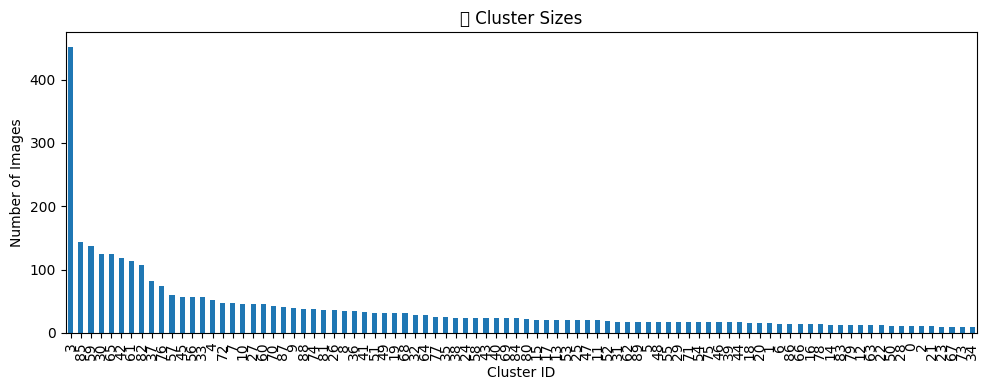

✅ Images organized into folders under: /content/drive/MyDrive/TESI - PoliTO/clustered_regions_configuration_1_ig


In [31]:
load_embeddings_and_cluster(integrated_gradients=True, name_configuration="configuration_1", min_cluster_size=10, n_neighbors=5, min_dist=0.1, metric="euclidean", copy_images_to_cluster_folders=True)

configuration_2
------- 
Embedding model: ig
Embedding path: final_region_embeddings_bioclip2.npz
Min cluster size: 10
Number of neighbors: 5
Min distance: 0.05
Metric: euclidean
-------



/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Clustered...
Cluster mapping saved to /content/drive/MyDrive/TESI - PoliTO/region_cluster_mapping.csv
📊 Total clusters (excluding noise): 74
⚠️ Noise points: 1546

📦 Cluster sizes:
cluster_id
-1     1546
 0       12
 1      457
 2       14
 3     1636
       ... 
 69      58
 70      12
 71      47
 72      44
 73      20
Name: count, Length: 75, dtype: int64

📏 Cluster compactness (avg. distance to centroid):
    cluster_id  size  avg_intra_dist
52          52    28       10.946908
53          53    14       10.979757
54          54   112       13.202820
66          66    30       13.389560
13          13    37       13.773442
..         ...   ...             ...
22          22    20       18.597399
44          44    13       18.654961
48          48    13       18.920000
43          43   125       19.036373
3            3  1636       19.136501

[74 rows x 3 columns]
📦 Total samples: 5931
⚠️ Noise points: 1546 (26.07%)
🔢 Number of clusters (excluding noise): 74

📉 Cluster size stats:


/tmp/ipython-input-634327281.py:36: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


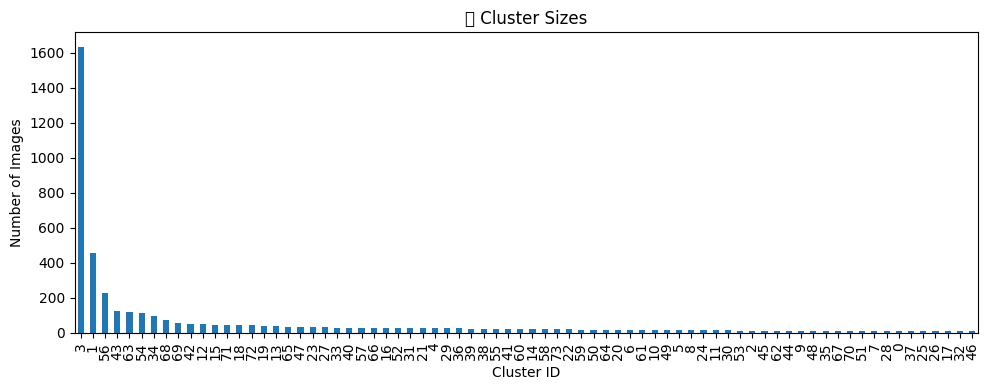

✅ Images organized into folders under: /content/drive/MyDrive/TESI - PoliTO/clustered_regions_configuration_2_ig


In [34]:
load_embeddings_and_cluster(integrated_gradients=True, name_configuration="configuration_2", min_cluster_size=10, n_neighbors=5, min_dist=0.05, metric="euclidean", copy_images_to_cluster_folders=True)

configuration_3
------- 
Embedding model: ig
Embedding path: final_region_embeddings_bioclip2.npz
Min cluster size: 10
Number of neighbors: 10
Min distance: 0.05
Metric: euclidean
-------



/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Clustered...
Cluster mapping saved to /content/drive/MyDrive/TESI - PoliTO/region_cluster_mapping.csv
📊 Total clusters (excluding noise): 65
⚠️ Noise points: 1726

📦 Cluster sizes:
cluster_id
-1     1726
 0       17
 1      251
 2       32
 3       25
       ... 
 60      57
 61      11
 62      24
 63      12
 64      24
Name: count, Length: 66, dtype: int64

📏 Cluster compactness (avg. distance to centroid):
    cluster_id  size  avg_intra_dist
12          12    60       12.265692
20          20    22       12.730228
11          11    18       12.955242
55          55    14       13.015638
53          53    11       13.198746
..         ...   ...             ...
18          18    18       18.512215
28          28    18       18.927998
27          27   316       18.991228
29          29   219       19.221670
1            1   251       19.431932

[65 rows x 3 columns]
📦 Total samples: 5931
⚠️ Noise points: 1726 (29.10%)
🔢 Number of clusters (excluding noise): 65

📉 Cluster size stats:


/tmp/ipython-input-634327281.py:36: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


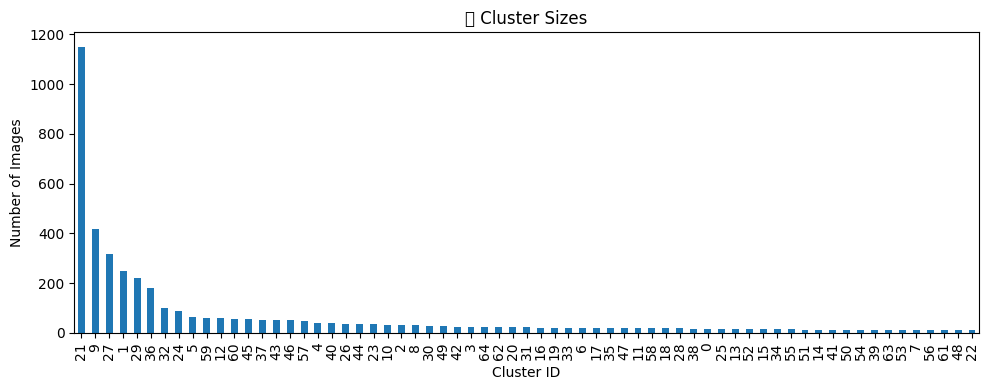

✅ Images organized into folders under: /content/drive/MyDrive/TESI - PoliTO/clustered_regions_configuration_3_ig


In [35]:
load_embeddings_and_cluster(integrated_gradients=True, name_configuration="configuration_3", min_cluster_size=10, n_neighbors=10, min_dist=0.05, metric="euclidean", copy_images_to_cluster_folders=True)

In [ ]:
output_base_dir = "/content/drive/MyDrive/TESI - PoliTO/clustered_regions_1"
organize_images_by_cluster(csv_path, output_base_dir)

✅ Images organized into folders under: /content/drive/MyDrive/TESI - PoliTO/clustered_regions_1
